# Prediksi Customer Churn

# UAS BENGKEL KODING

### Universitas Dian Nuswantoro

**Dataset**: Sales & Marketing Dataset

**Sumber**:  https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset

### Nama: Iqbal Ika Rahmawan

### NIM: A11.2023.15482

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# Sklearn - Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# EDA

### 1. Menampilkan 5 baris pertama, informasi dataset, dan statistik deskriptif.

In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/datasets/Sales - Marketing customer dataset.csv')
print(f'Jumlah Dataset yaitu {df.shape[0]} baris dan {df.shape[1]} kolom.')

Jumlah Dataset yaitu 15000 baris dan 30 kolom.


In [3]:
# Menampilkan 5 data teratas
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [5]:
# Statistik deskriptif untuk kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,15000.0,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.0,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.0,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.0,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.0,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.0,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.0,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.0,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.0,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.0,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


In [6]:
# Statistik numerik untuk kolom kategorikal
df.describe(include="object").T

,count,unique,top,freq
gender,14262,3,Male,6844
country,15000,5,Germany,3072
city,15000,7,London,2236
signup_date,15000,1000,2024-09-20 00:00:00,29
last_purchase_date,15000,800,2025-01-17 00:00:00,32
acquisition_channel,15000,5,Organic,3055
device_type,15000,3,Tablet,5043
subscription_type,15000,2,Monthly,7666
coupon_code,8867,3,REF10,2995
payment_method,15000,5,UPI,3105


### 2. Presentase Missing Value & Visualisasi Hasilnya

In [7]:
# Menghitung jumlah dan persentase missing value tiap kolom
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "jumlah_missing": missing_count,
    "persentase_missing (%)": missing_percent
}).sort_values("persentase_missing (%)", ascending=False)

# Menampilkan kolom yang memiliki missing value
missing_df[missing_df["jumlah_missing"] > 0]

,jumlah_missing,persentase_missing (%)
coupon_code,6133,40.89
age,1200,8.00
total_spent,1050,7.00
gender,738,4.92
satisfaction_score,702,4.68


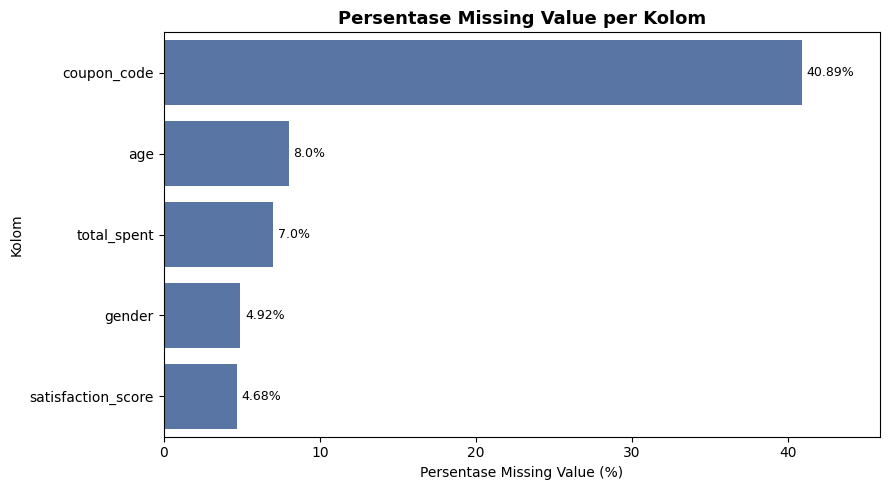

In [8]:
# Visualisasi persentase missing value dalam diagram batang
missing_plot_df = missing_df[missing_df["persentase_missing (%)"] > 0]

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=missing_plot_df["persentase_missing (%)"],
    y=missing_plot_df.index,
    color="#4C72B0"
)

for i, v in enumerate(missing_plot_df["persentase_missing (%)"]):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)

plt.title("Persentase Missing Value per Kolom", fontsize=13, fontweight="bold")
plt.xlabel("Persentase Missing Value (%)")
plt.ylabel("Kolom")
plt.xlim(0, missing_plot_df["persentase_missing (%)"].max() + 5)
plt.tight_layout()
plt.show()

### 3. Visualisasi Distribusi Variabel Target (Churn)

In [9]:
# Menghitung jumlah dan persentase tiap kelas churn
churn_count = df["churn"].value_counts().sort_index()
churn_percent = (churn_count / len(df) * 100)

churn_summary = pd.DataFrame({
    "jumlah": churn_count,
    "persentase (%)": churn_percent
})
churn_summary.index = churn_summary.index.map({0: "Bertahan (0)", 1: "Churn (1)"})
churn_summary

,jumlah,persentase (%)
churn,,
Bertahan (0),12702,84.68
Churn (1),2298,15.32


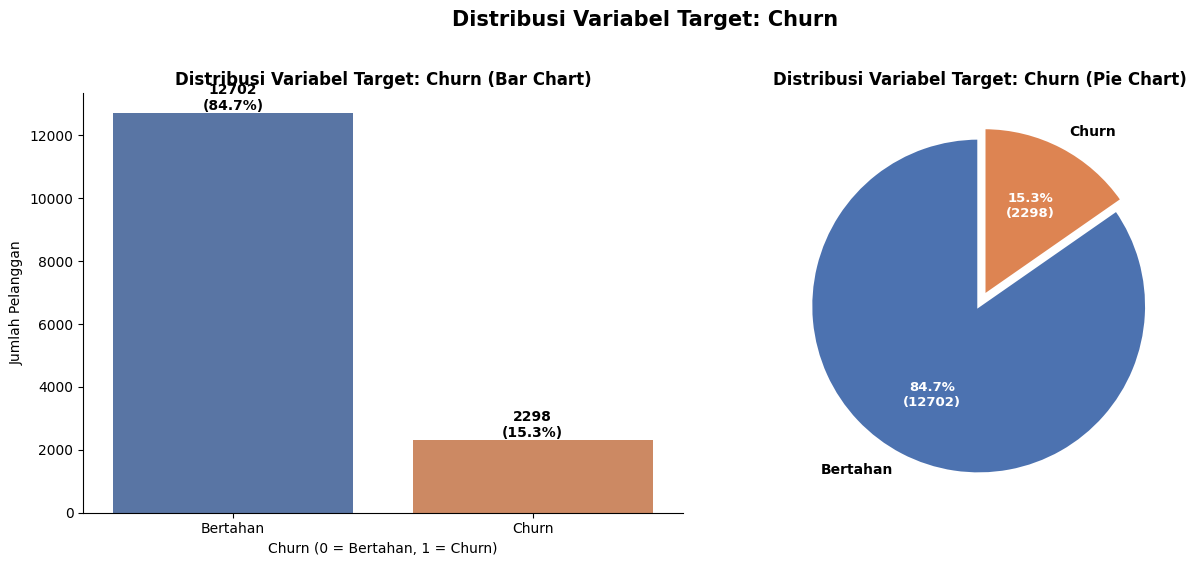

In [10]:
# Hitung jumlah dan persentase churn
churn_counts = df['churn'].value_counts().sort_index()
total = len(df)
labels = ["Bertahan", "Churn"]
colors = ["#4C72B0", "#DD8452"]

# Setup figure dengan 2 subplot (bar chart & pie chart)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bar Chart
ax1 = axes[0]
sns.countplot(x="churn", data=df, hue="churn", palette=colors, legend=False, ax=ax1)

for p in ax1.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax1.annotate(f"{count}\n({pct:.1f}%)",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_title("Distribusi Variabel Target: Churn (Bar Chart)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Churn (0 = Bertahan, 1 = Churn)")
ax1.set_ylabel("Jumlah Pelanggan")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(labels)
ax1.spines[['top', 'right']].set_visible(False)

# Pie Chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    churn_counts,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*total))})",
    colors=colors,
    startangle=90,
    explode=(0.02, 0.05),
    shadow=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for text in texts:
    text.set_fontsize(10)
    text.set_fontweight("bold")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(9.5)
    autotext.set_fontweight("bold")

ax2.set_title("Distribusi Variabel Target: Churn (Pie Chart)", fontsize=12, fontweight="bold")

# Judul keseluruhan
fig.suptitle("Distribusi Variabel Target: Churn", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("churn_distribution_bar_pie.png", bbox_inches="tight", dpi=150)
plt.show()

### 4. Heatmap Korelasi Fitur Numerik

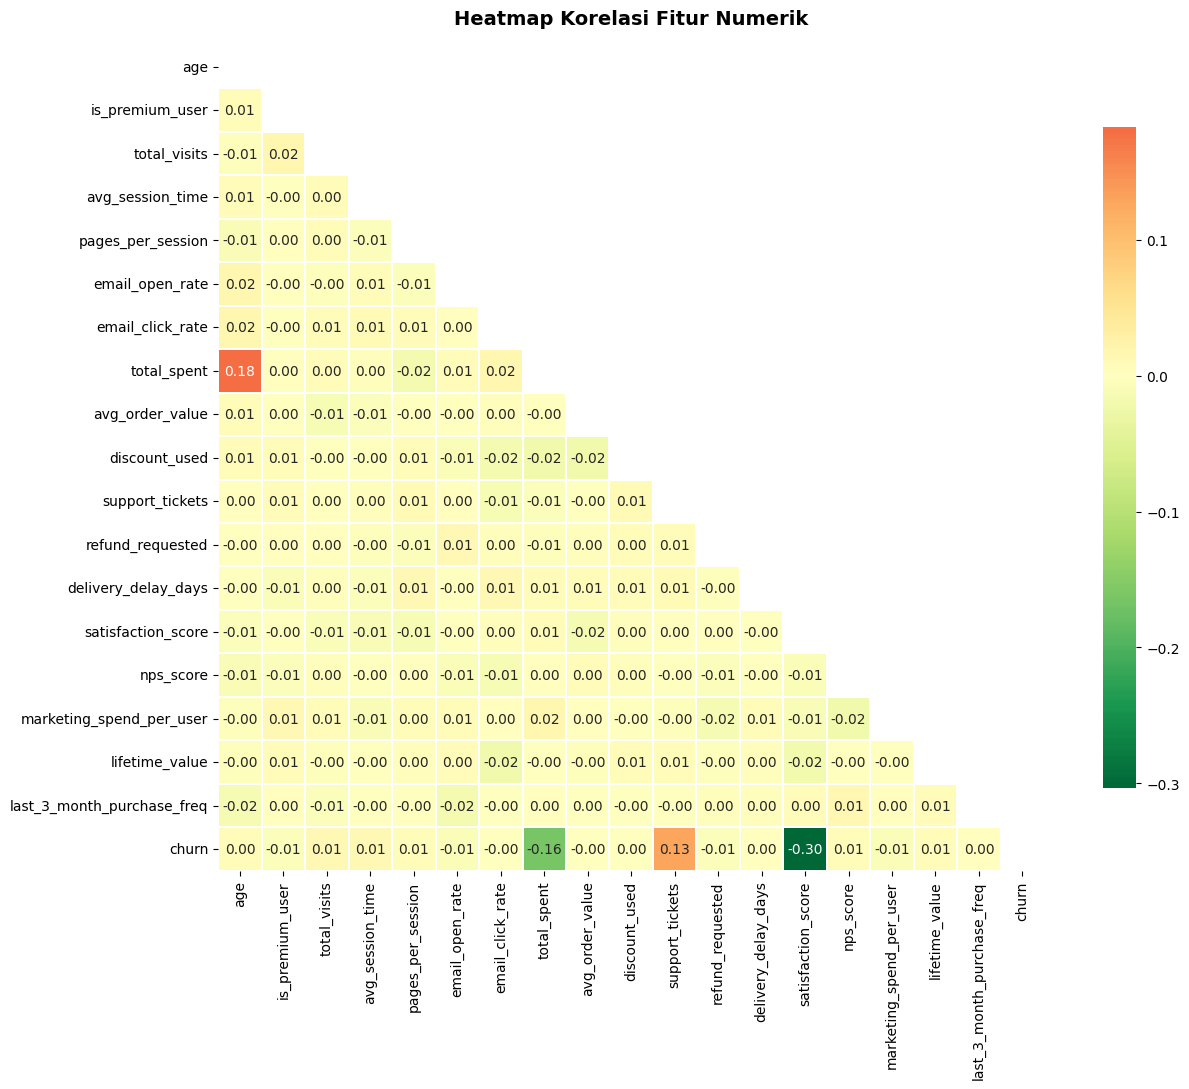

In [11]:
# Memilih kolom numerik (termasuk churn) untuk dianalisis korelasinya
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('customer_id')  # Tidak fitur numerik

# Menghitung matrix korelasi
corr_matrix = df[numeric_cols].corr()

# Visualisasi heatmap
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask segitiga atas biar ga redundan

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0,
            linewidths=1.2, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8})

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
# Melihat korelasi tiap fitur numerik secara spesifik terhadap variabel target churn
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print('\nTop 10 fitur berkorelasi paling tinggi terhadap Churn:')
print(churn_corr.head(10).to_string())


Top 10 fitur berkorelasi paling tinggi terhadap Churn:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871


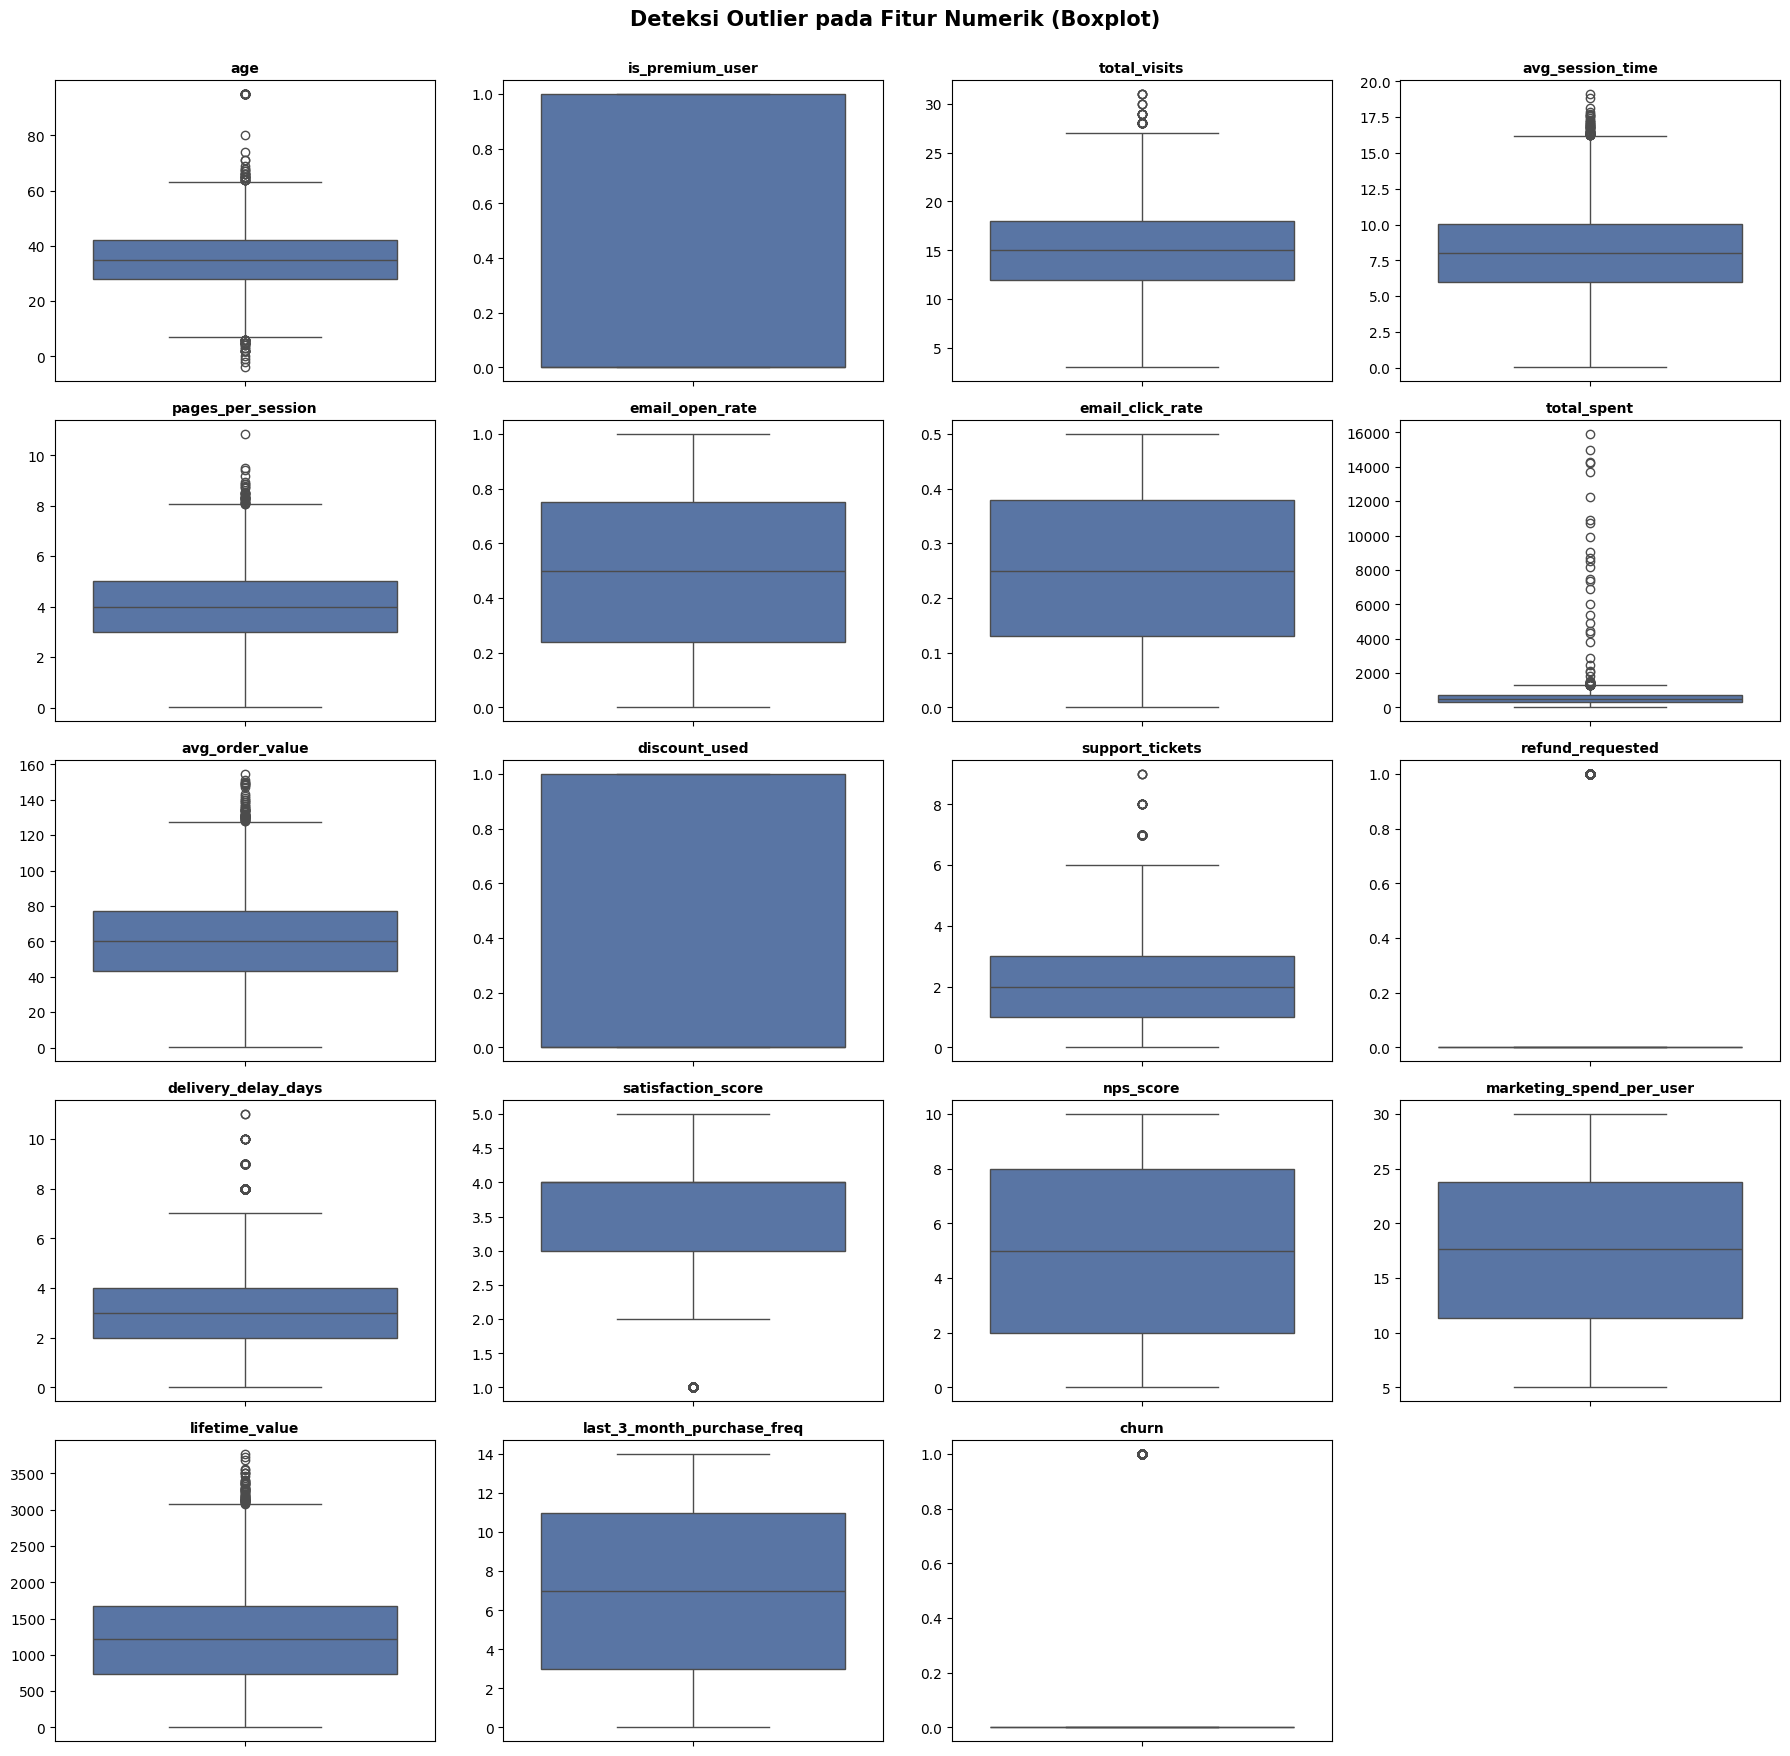

Ringkasan Jumlah Outlier per Fitur Numerik (Metode IQR):
                            Jumlah Outlier
churn                                 2298
refund_requested                      2215
satisfaction_score                     753
delivery_delay_days                    184
age                                     89
support_tickets                         79
total_spent                             78
lifetime_value                          56
avg_order_value                         54
avg_session_time                        45
total_visits                            39
pages_per_session                       33
is_premium_user                          0
email_open_rate                          0
email_click_rate                         0
discount_used                            0
nps_score                                0
marketing_spend_per_user                 0
last_3_month_purchase_freq               0


In [13]:
# Visualisasi outlier menggunakan boxplot untuk setiap fitur numerik
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

# Menyembunyikan subplot kosong jika ada
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Deteksi Outlier pada Fitur Numerik (Boxplot)', fontsize=15, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

# Menghitung jumlah outlier tiap fitur numerik menggunakan metode IQR
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = outlier_count

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Jumlah Outlier'])
outlier_df = outlier_df.sort_values('Jumlah Outlier', ascending=False)
print('Ringkasan Jumlah Outlier per Fitur Numerik (Metode IQR):')
print(outlier_df.to_string())

# Direct Modeling

### 1. Menetapkan Variabel Target (y) dan Fitur Prediktor (X)

In [14]:
# Load dataset
df_direct = df.copy()

# Menetapkan variabel target dan fitur prediktor
# Untuk Direct Modeling, gunakan semua kolom numerik
numeric_cols_direct = df_direct.select_dtypes(include=['number']).columns.tolist()
numeric_cols_direct.remove('customer_id')  # Hapus ID karena bukan fitur
numeric_cols_direct.remove('churn')        # Hapus target

X = df_direct[numeric_cols_direct].copy()
y = df_direct['churn']

# Imputasi sederhana (median) untuk menangani NaN — minimal handling agar model dapat berjalan
# Ini bukan preprocessing penuh; hanya syarat minimum agar scikit-learn bisa menerima data
nan_cols = X.columns[X.isnull().any()].tolist()
if nan_cols:
    print('Kolom dengan missing value dan jumlahnya:')
    print(X[nan_cols].isnull().sum())
    for col in nan_cols:
        X[col].fillna(X[col].median(), inplace=True)
    print(f'\nImputasi median diterapkan pada: {nan_cols}')
else:
    print('Tidak ada missing value pada fitur numerik.')

print(f'\nJumlah fitur prediktor (numerik): {X.shape[1]}')
print(f'Fitur yang digunakan: {numeric_cols_direct}')
print(f'\nJumlah sampel: {X.shape[0]}')
print('\nDistribusi target (churn):')
print(y.value_counts())

Kolom dengan missing value dan jumlahnya:
age                   1200
total_spent           1050
satisfaction_score     702
dtype: int64

Imputasi median diterapkan pada: ['age', 'total_spent', 'satisfaction_score']

Jumlah fitur prediktor (numerik): 18
Fitur yang digunakan: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Jumlah sampel: 15000

Distribusi target (churn):
churn
0    12702
1     2298
Name: count, dtype: int64


### 2. Train–Test Split

In [15]:
# Membagi data menjadi data latih dan data uji dengan proporsi 80:20
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data latih : {X_train_d.shape[0]} sampel')
print(f'Ukuran data uji   : {X_test_d.shape[0]} sampel')
print(f'Proporsi churn (train): {y_train_d.mean():.4f}')
print(f'Proporsi churn (test) : {y_test_d.mean():.4f}')

Ukuran data latih : 12000 sampel
Ukuran data uji   : 3000 sampel
Proporsi churn (train): 0.1532
Proporsi churn (test) : 0.1533


### 3. Pemilihan Tiga Model

In [16]:
# ── 1. Model Konvensional: Logistic Regression ──
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# ── 2. Ensemble Bagging: Random Forest ──
model_rf = RandomForestClassifier(random_state=42)

# ── 3. Ensemble Voting: Logistic Regression + SVM + KNN ──
lr_base  = LogisticRegression(random_state=42, max_iter=1000)
svm_base = SVC(probability=True, random_state=42)
knn_base = KNeighborsClassifier()

model_vc = VotingClassifier(
    estimators=[('lr', lr_base), ('svm', svm_base), ('knn', knn_base)],
    voting='soft'
)

models_direct = {
    'Logistic Regression (Konvensional)': model_lr,
    'Random Forest (Ensemble Bagging)'  : model_rf,
    'Voting Classifier (LR+SVM+KNN)'   : model_vc,
}

print('Model yang akan digunakan:')
for name in models_direct:
    print(f'  - {name}')

Model yang akan digunakan:
  - Logistic Regression (Konvensional)
  - Random Forest (Ensemble Bagging)
  - Voting Classifier (LR+SVM+KNN)


### 4. Pelatihan Model Tanpa Preprocessing dan Hyperparameter Tuning

In [17]:
import time

trained_direct = {}

for name, model in models_direct.items():
    print(f'Melatih model: {name} ...')
    start = time.time()
    model.fit(X_train_d, y_train_d)
    elapsed = time.time() - start
    trained_direct[name] = model
    print(f'  Selesai dalam {elapsed:.2f} detik\n')

print('Semua model berhasil dilatih!')

Melatih model: Logistic Regression (Konvensional) ...
  Selesai dalam 1.40 detik

Melatih model: Random Forest (Ensemble Bagging) ...
  Selesai dalam 3.01 detik

Melatih model: Voting Classifier (LR+SVM+KNN) ...
  Selesai dalam 26.99 detik

Semua model berhasil dilatih!


### 5. Evaluasi Performa Model

In [18]:
# Fungsi evaluasi
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    return y_pred, {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results_direct = []
preds_direct   = {}

for name, model in trained_direct.items():
    y_pred, metrics = evaluate_model(name, model, X_test_d, y_test_d)
    results_direct.append(metrics)
    preds_direct[name] = y_pred

# Tampilkan tabel metrik
results_df_direct = pd.DataFrame(results_direct).set_index('Model')
print('RINGKASAN METRIK EVALUASI - DIRECT MODELING')
print(results_df_direct.to_string(float_format=lambda x: f'{x:.4f}'))

RINGKASAN METRIK EVALUASI - DIRECT MODELING
                                    Accuracy  Precision  Recall  F1-Score
Model                                                                    
Logistic Regression (Konvensional)    0.8437     0.4667  0.1370    0.2118
Random Forest (Ensemble Bagging)      0.8470     0.5015  0.3696    0.4255
Voting Classifier (LR+SVM+KNN)        0.8457     0.4483  0.0283    0.0532


In [19]:
# Classification Report lengkap untuk setiap model
for name, model in trained_direct.items():
    y_pred = preds_direct[name]
    print(f'Classification Report: {name}')
    print(classification_report(y_test_d, y_pred, target_names=['Bertahan (0)', 'Churn (1)']))

Classification Report: Logistic Regression (Konvensional)
              precision    recall  f1-score   support

Bertahan (0)       0.86      0.97      0.91      2540
   Churn (1)       0.47      0.14      0.21       460

    accuracy                           0.84      3000
   macro avg       0.66      0.55      0.56      3000
weighted avg       0.80      0.84      0.81      3000

Classification Report: Random Forest (Ensemble Bagging)
              precision    recall  f1-score   support

Bertahan (0)       0.89      0.93      0.91      2540
   Churn (1)       0.50      0.37      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000

Classification Report: Voting Classifier (LR+SVM+KNN)
              precision    recall  f1-score   support

Bertahan (0)       0.85      0.99      0.92      2540
   Churn (1)       0.45      0.03      0.05       460

    accuracy  

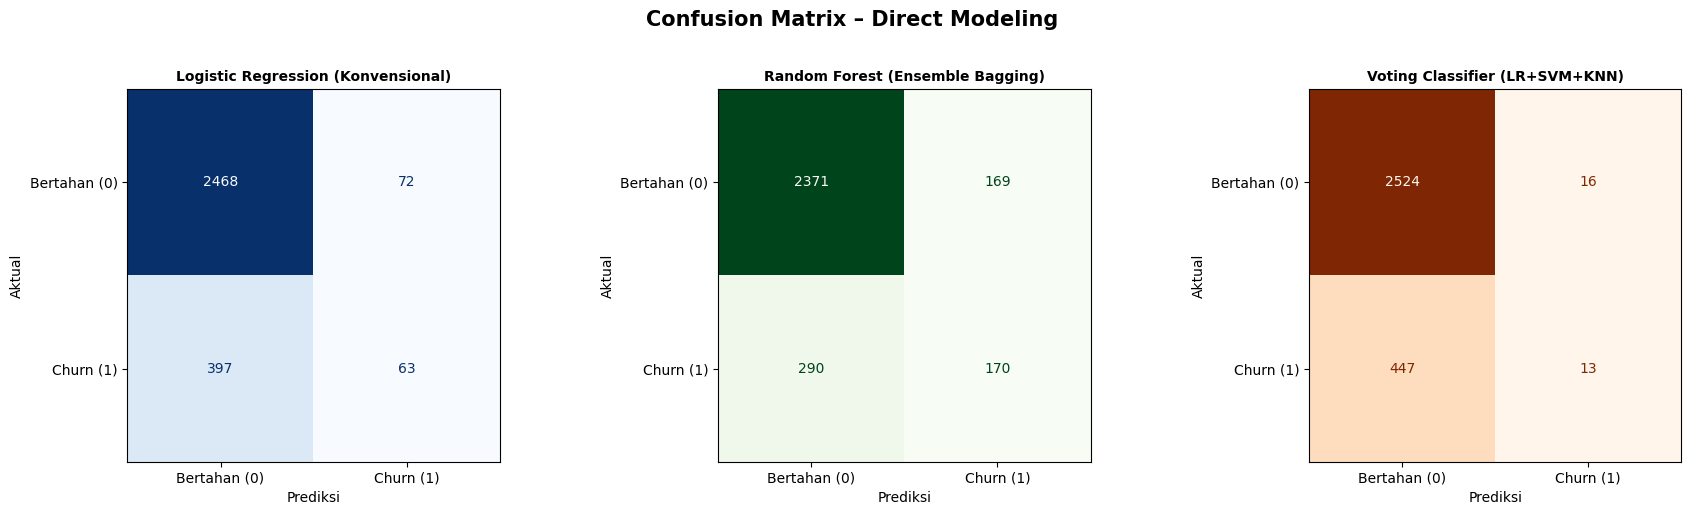

In [20]:
# Visualisasi Confusion Matrix untuk setiap model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix – Direct Modeling', fontsize=15, fontweight='bold', y=1.02)

colors_cm = ['Blues', 'Greens', 'Oranges']

for ax, (name, model), cmap in zip(axes, trained_direct.items(), colors_cm):
    y_pred = preds_direct[name]
    cm = confusion_matrix(y_test_d, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Bertahan (0)', 'Churn (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format='d')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_direct.png', bbox_inches='tight', dpi=150)
plt.show()

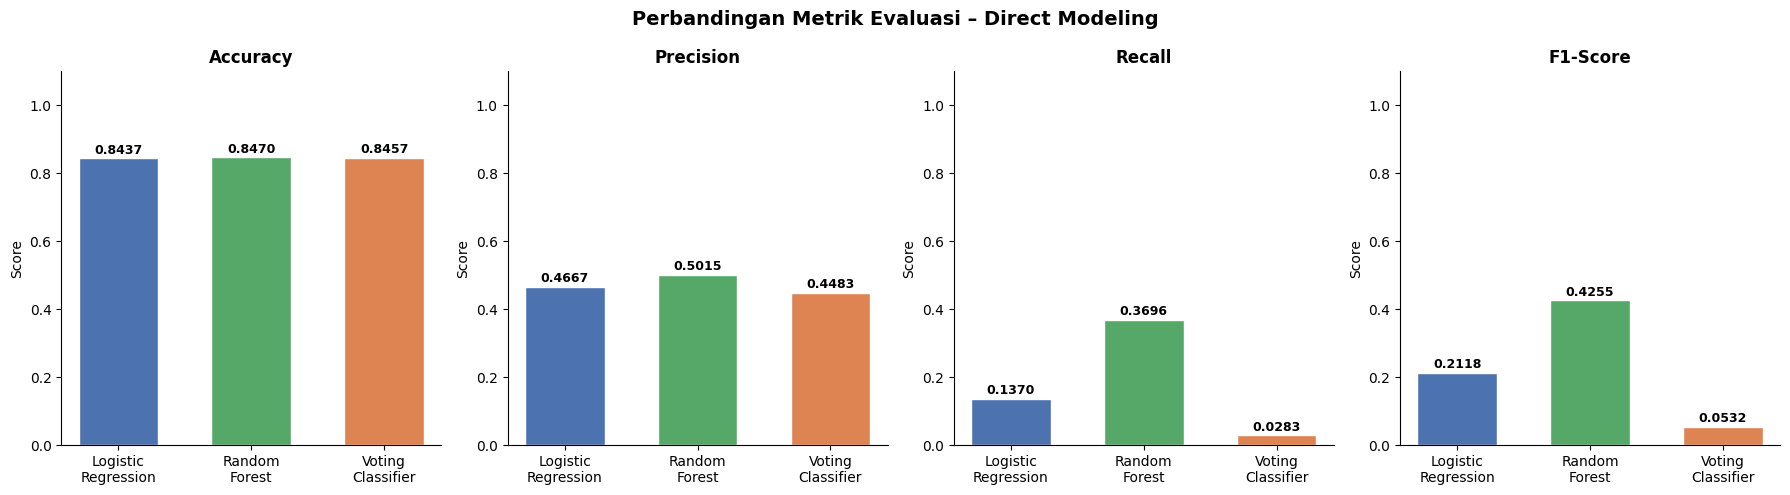


Model terbaik berdasarkan F1-Score pada Direct Modeling:
Random Forest (Ensemble Bagging) (F1-Score = 0.4255)


In [21]:
# Visualisasi perbandingan metrik antar model
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names_short = ['Logistic\nRegression', 'Random\nForest', 'Voting\nClassifier']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Perbandingan Metrik Evaluasi – Direct Modeling',
             fontsize=14, fontweight='bold')

palette = ['#4C72B0', '#55A868', '#DD8452']

for ax, metric in zip(axes, metrics_names):
    values = results_df_direct[metric].values
    bars = ax.bar(model_names_short, values, color=palette, edgecolor='white', width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_comparison_direct.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nModel terbaik berdasarkan F1-Score pada Direct Modeling:')
best_direct = results_df_direct['F1-Score'].idxmax()
print(f'{best_direct} (F1-Score = {results_df_direct.loc[best_direct, "F1-Score"]:.4f})')

# Modeling Dengan Preprocessing

### 1. Preprocessing Data

In [22]:
# Load dataset ke dataframe baru khusus preprocessing
df_prep = df.copy()
print(f'Shape awal: {df_prep.shape}')
print(f'\nMissing value per kolom:')
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])
print(f'\nJumlah duplikat: {df_prep.duplicated().sum()}')

Shape awal: (15000, 30)

Missing value per kolom:
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64

Jumlah duplikat: 0


In [23]:
# Menghapus fitur tidak relevan & feature engineering dari kolom tanggal
# Feature Engineering dari tanggal
df_prep['signup_date']        = pd.to_datetime(df_prep['signup_date'])
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'])

ref_date = df_prep['last_purchase_date'].max()   # tanggal referensi = transaksi terakhir
df_prep['tenure_days']             = (ref_date - df_prep['signup_date']).dt.days
df_prep['days_since_last_purchase'] = (ref_date - df_prep['last_purchase_date']).dt.days

# Drop kolom tidak relevan
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_prep.drop(columns=drop_cols, inplace=True)

print('Kolom dihapus:', drop_cols)
print('Fitur baru ditambahkan: tenure_days, days_since_last_purchase')
print(f'Shape setelah penghapusan fitur: {df_prep.shape}')

Kolom dihapus: ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
Fitur baru ditambahkan: tenure_days, days_since_last_purchase
Shape setelah penghapusan fitur: (15000, 28)


In [24]:
# Handle duplikasi
dup_before = df_prep.duplicated().sum()
df_prep.drop_duplicates(inplace=True)
dup_after = df_prep.duplicated().sum()
print(f'Duplikat sebelum : {dup_before}')
print(f'Duplikat sesudah : {dup_after}')
print(f'Shape             : {df_prep.shape}')

Duplikat sebelum : 0
Duplikat sesudah : 0
Shape             : (15000, 28)


In [25]:
# Handle missing value
mv = df_prep.isnull().sum()
mv = mv[mv > 0]
mv_pct = (mv / len(df_prep) * 100).round(2)
print('Kolom dengan missing value:')
print(pd.DataFrame({'Jumlah': mv, 'Persentase (%)': mv_pct}))

# gender       : kategorikal → isi dengan modus
# age          : numerik     → isi dengan median (robust terhadap outlier)
# total_spent  : numerik     → isi dengan median
# satisfaction_score: numerik→ isi dengan median

df_prep['gender'].fillna(df_prep['gender'].mode()[0], inplace=True)
for col in ['age', 'total_spent', 'satisfaction_score']:
    df_prep[col].fillna(df_prep[col].median(), inplace=True)

print(f'\nMissing value setelah imputasi: {df_prep.isnull().sum().sum()}')

Kolom dengan missing value:
                    Jumlah  Persentase (%)
gender                 738            4.92
age                   1200            8.00
total_spent           1050            7.00
satisfaction_score     702            4.68

Missing value setelah imputasi: 0


In [26]:
# Handle outlier
exclude_from_capping = ['is_premium_user', 'discount_used', 'refund_requested', 'churn']
num_cols_prep = df_prep.select_dtypes(include='number').columns
cap_cols = [c for c in num_cols_prep if c not in exclude_from_capping]

outlier_summary = []
for col in cap_cols:
    Q1  = df_prep[col].quantile(0.25)
    Q3  = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    if n_out > 0:
        df_prep[col] = df_prep[col].clip(lower, upper)
        outlier_summary.append({'Kolom': col, 'Outlier Ditangani': n_out, 'Lower': round(lower,2), 'Upper': round(upper,2)})

print('Outlier yang ditangani dengan capping:')
print(pd.DataFrame(outlier_summary).to_string(index=False))

Outlier yang ditangani dengan capping:
              Kolom  Outlier Ditangani   Lower   Upper
                age                218   11.00   59.00
       total_visits                 39    3.00   27.00
   avg_session_time                 45   -0.15   16.19
  pages_per_session                 33   -0.05    8.05
        total_spent                119 -232.53 1233.57
    avg_order_value                 54   -7.75  127.67
    support_tickets                 79   -2.00    6.00
delivery_delay_days                184   -1.00    7.00
 satisfaction_score                753    1.50    5.50
     lifetime_value                 56 -663.54 3082.70


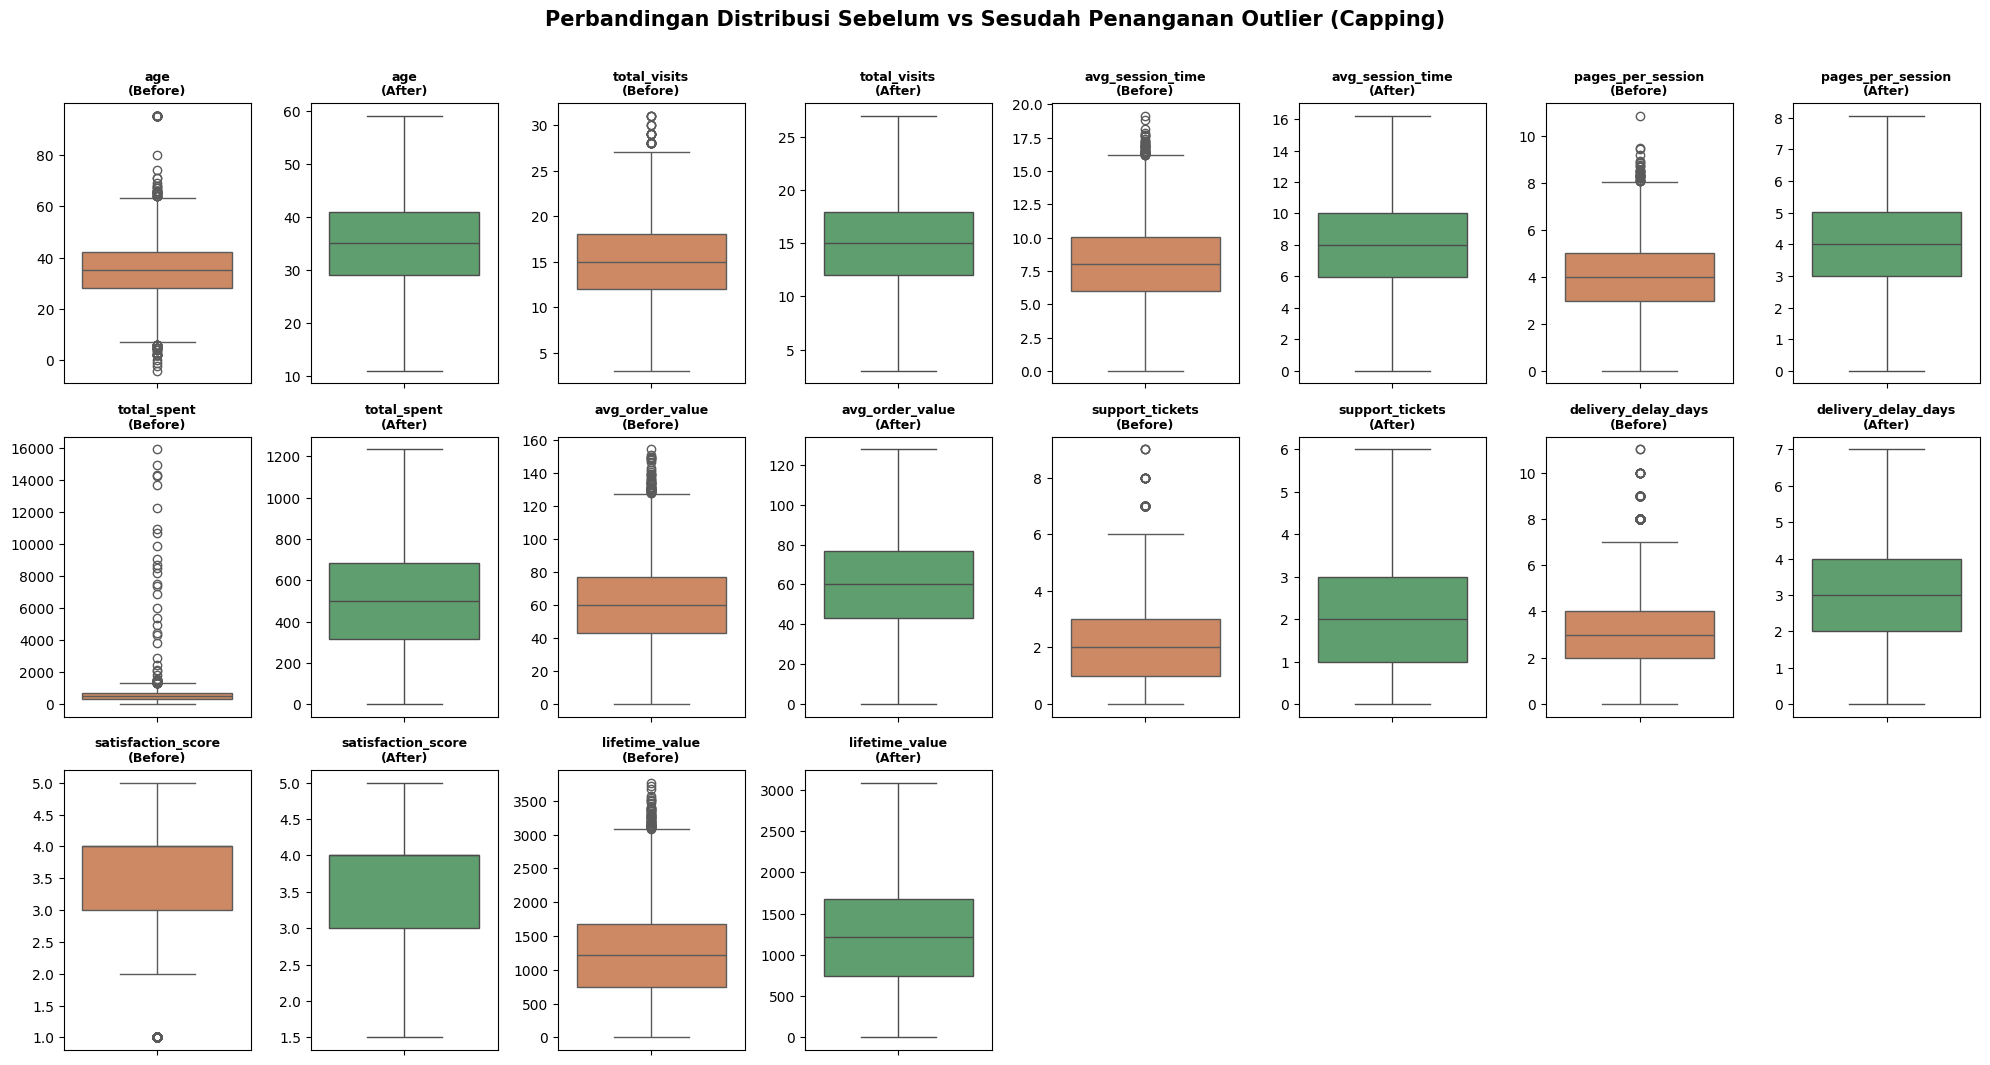

In [27]:
# Visualisasi hasil penanganan outlier (before vs after capping)
cols_to_plot = [item['Kolom'] for item in outlier_summary]

n_cols_plot = 4
n_rows_plot = int(np.ceil(len(cols_to_plot) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot * 2, figsize=(20, 3.5 * n_rows_plot))
axes = axes.reshape(n_rows_plot, n_cols_plot * 2)

for i, col in enumerate(cols_to_plot):
    row = i // n_cols_plot
    pos = (i % n_cols_plot) * 2

    sns.boxplot(y=df[col], ax=axes[row, pos], color='#DD8452')
    axes[row, pos].set_title(f'{col}\n(Before)', fontsize=9, fontweight='bold')
    axes[row, pos].set_ylabel('')

    sns.boxplot(y=df_prep[col], ax=axes[row, pos + 1], color='#55A868')
    axes[row, pos + 1].set_title(f'{col}\n(After)', fontsize=9, fontweight='bold')
    axes[row, pos + 1].set_ylabel('')

# Menyembunyikan subplot kosong jika ada
total_used = len(cols_to_plot) * 2
for j in range(total_used, n_rows_plot * n_cols_plot * 2):
    fig.delaxes(axes.flatten()[j])

plt.suptitle('Perbandingan Distribusi Sebelum vs Sesudah Penanganan Outlier (Capping)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# Encoding fitur kategorikal
# Mengidentifikasi kolom kategorikal yang tersisa
cat_cols = df_prep.select_dtypes(include=['object']).columns.tolist()
print('Kolom kategorikal:', cat_cols)

# Label Encoding untuk kolom biner
le = LabelEncoder()
binary_encode_cols = ['gender', 'subscription_type']
for col in binary_encode_cols:
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))

# One-Hot Encoding untuk kolom nominal
ohe_cols = ['country', 'city', 'acquisition_channel', 'device_type', 'payment_method']
df_prep = pd.get_dummies(df_prep, columns=ohe_cols, drop_first=True)

print(f'Shape setelah encoding: {df_prep.shape}')
print(f'Total fitur: {df_prep.shape[1] - 1} (tidak termasuk target)')

Kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
Shape setelah encoding: (15000, 43)
Total fitur: 42 (tidak termasuk target)


### 2. Menetapkan Fitur Prediktor (X) dan Target (y) Setelah Preprocessing

Distribusi target SEBELUM handling imbalanced:
churn
0    12702
1     2298
Name: count, dtype: int64
churn
0    0.8468
1    0.1532
Name: proportion, dtype: float64


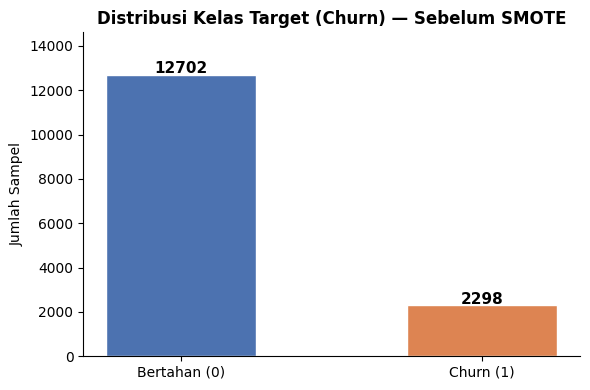


Data tidak seimbang: kelas 0 (85%) >> kelas 1 (15%)
Strategi: SMOTE (Synthetic Minority Oversampling Technique)
SMOTE diterapkan HANYA pada data latih setelah splitting untuk mencegah data leakage.


In [29]:
# Penanganan class imbalance dengan SMOTE
# Cek distribusi kelas sebelum handling
print('Distribusi target SEBELUM handling imbalanced:')
print(df_prep['churn'].value_counts())
print(df_prep['churn'].value_counts(normalize=True).round(4))

# Visualisasi distribusi kelas — single bar chart
fig, ax = plt.subplots(figsize=(6, 4))
counts_before = df_prep['churn'].value_counts().sort_index()
bars = ax.bar(['Bertahan (0)', 'Churn (1)'], counts_before.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts_before.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(val), ha='center', fontweight='bold', fontsize=11)
ax.set_title('Distribusi Kelas Target (Churn) — Sebelum SMOTE',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Sampel')
ax.set_ylim(0, counts_before.max() * 1.15)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('class_distribution_before_smote.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nData tidak seimbang: kelas 0 (85%) >> kelas 1 (15%)')
print('Strategi: SMOTE (Synthetic Minority Oversampling Technique)')
print('SMOTE diterapkan HANYA pada data latih setelah splitting untuk mencegah data leakage.')

In [30]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

print(f'Jumlah fitur prediktor : {X_prep.shape[1]}')
print(f'Jumlah sampel          : {X_prep.shape[0]}')
print(f'\nDistribusi target (churn):')
print(y_prep.value_counts())
print(f'\nDaftar fitur:')
print(X_prep.columns.tolist())

Jumlah fitur prediktor : 42
Jumlah sampel          : 15000

Distribusi target (churn):
churn
0    12702
1     2298
Name: count, dtype: int64

Daftar fitur:
['gender', 'age', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'tenure_days', 'days_since_last_purchase', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_Hamburg', 'city_London', 'city_Mumbai', 'city_New York', 'acquisition_channel_Facebook Ads', 'acquisition_channel_Google Ads', 'acquisition_channel_Organic', 'acquisition_channel_Referral', 'device_type_Mobile', 'device_type_Tablet', 'payment_method_Card', 'payment_method_PayPal', 'payment_method_SEPA', 'payment_method_UPI

### 3. Train-Test Split

Ukuran data latih (sebelum SMOTE): 12000 sampel
Ukuran data uji                  : 3000 sampel
Scaling StandardScaler diterapkan (fit pada train, transform pada test).

Distribusi kelas SEBELUM SMOTE (train):
churn
0    10162
1     1838
Name: count, dtype: int64

Distribusi kelas SESUDAH SMOTE (train):
churn
1    10162
0    10162
Name: count, dtype: int64

Ukuran data latih setelah SMOTE: 20324 sampel


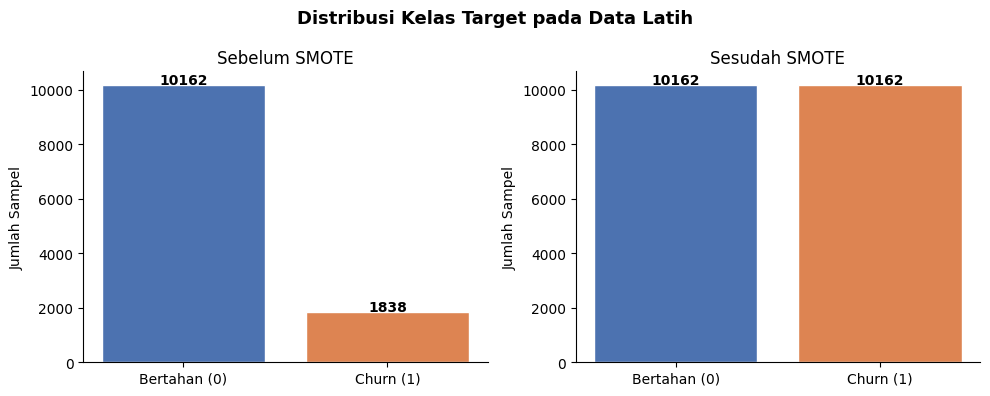

In [31]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

print(f'Ukuran data latih (sebelum SMOTE): {X_train_p.shape[0]} sampel')
print(f'Ukuran data uji                  : {X_test_p.shape[0]} sampel')

# Scaling setelah splitting (mencegah data leakage)
scaler = StandardScaler()
X_train_p_sc = scaler.fit_transform(X_train_p)   # fit hanya pada data latih
X_test_p_sc  = scaler.transform(X_test_p)         # hanya transform pada data uji

print('Scaling StandardScaler diterapkan (fit pada train, transform pada test).')

# SMOTE setelah scaling, HANYA pada data latih
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_p_res, y_train_p_res = smote.fit_resample(X_train_p_sc, y_train_p)

print(f'\nDistribusi kelas SEBELUM SMOTE (train):')
print(pd.Series(y_train_p).value_counts())
print(f'\nDistribusi kelas SESUDAH SMOTE (train):')
print(pd.Series(y_train_p_res).value_counts())
print(f'\nUkuran data latih setelah SMOTE: {X_train_p_res.shape[0]} sampel')

# Visualisasi perbandingan distribusi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribusi Kelas Target pada Data Latih', fontsize=13, fontweight='bold')

before = pd.Series(y_train_p).value_counts().sort_index()
after  = pd.Series(y_train_p_res).value_counts().sort_index()

axes[0].bar(['Bertahan (0)', 'Churn (1)'], before.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Sebelum SMOTE')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(['Bertahan (0)', 'Churn (1)'], after.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[1].set_title('Sesudah SMOTE')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('smote_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 4. Melatih Ketiga Model

In [32]:
# Definisi ulang model dengan konfigurasi yang sama seperti Direct Modeling
models_prep = {
    'Logistic Regression (Konvensional)': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest (Ensemble Bagging)'  : RandomForestClassifier(random_state=42),
    'Voting Classifier (LR+SVM+KNN)'   : VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('svm', SVC(probability=True, random_state=42)),
            ('knn', KNeighborsClassifier()),
        ],
        voting='soft'
    ),
}

trained_prep = {}

for name, model in models_prep.items():
    print(f'Melatih model: {name} ...')
    start = time.time()
    model.fit(X_train_p_res, y_train_p_res)
    elapsed = time.time() - start
    trained_prep[name] = model
    print(f'  Selesai dalam {elapsed:.2f} detik\n')

print('Semua model berhasil dilatih!')

Melatih model: Logistic Regression (Konvensional) ...
  Selesai dalam 0.11 detik

Melatih model: Random Forest (Ensemble Bagging) ...
  Selesai dalam 8.31 detik

Melatih model: Voting Classifier (LR+SVM+KNN) ...
  Selesai dalam 143.89 detik

Semua model berhasil dilatih!


### 5. Evaluasi Performa Model

In [33]:
results_prep = []
preds_prep   = {}

for name, model in trained_prep.items():
    y_pred = model.predict(X_test_p_sc)
    preds_prep[name] = y_pred
    results_prep.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test_p, y_pred),
        'Precision': precision_score(y_test_p, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test_p, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test_p, y_pred, zero_division=0),
    })

results_df_prep = pd.DataFrame(results_prep).set_index('Model')
print('RINGKASAN METRIK EVALUASI - MODELING DENGAN PREPROCESSING')
print(results_df_prep.to_string(float_format=lambda x: f'{x:.4f}'))

RINGKASAN METRIK EVALUASI - MODELING DENGAN PREPROCESSING
                                    Accuracy  Precision  Recall  F1-Score
Model                                                                    
Logistic Regression (Konvensional)    0.7580     0.3570  0.7217    0.4777
Random Forest (Ensemble Bagging)      0.8523     0.5150  0.6348    0.5686
Voting Classifier (LR+SVM+KNN)        0.8130     0.4234  0.6065    0.4987


In [34]:
# Classification Report lengkap per model
for name, y_pred in preds_prep.items():
    print(f'Classification Report: {name}')
    print(classification_report(y_test_p, y_pred, target_names=['Bertahan (0)', 'Churn (1)']))

Classification Report: Logistic Regression (Konvensional)
              precision    recall  f1-score   support

Bertahan (0)       0.94      0.76      0.84      2540
   Churn (1)       0.36      0.72      0.48       460

    accuracy                           0.76      3000
   macro avg       0.65      0.74      0.66      3000
weighted avg       0.85      0.76      0.79      3000

Classification Report: Random Forest (Ensemble Bagging)
              precision    recall  f1-score   support

Bertahan (0)       0.93      0.89      0.91      2540
   Churn (1)       0.51      0.63      0.57       460

    accuracy                           0.85      3000
   macro avg       0.72      0.76      0.74      3000
weighted avg       0.87      0.85      0.86      3000

Classification Report: Voting Classifier (LR+SVM+KNN)
              precision    recall  f1-score   support

Bertahan (0)       0.92      0.85      0.89      2540
   Churn (1)       0.42      0.61      0.50       460

    accuracy  

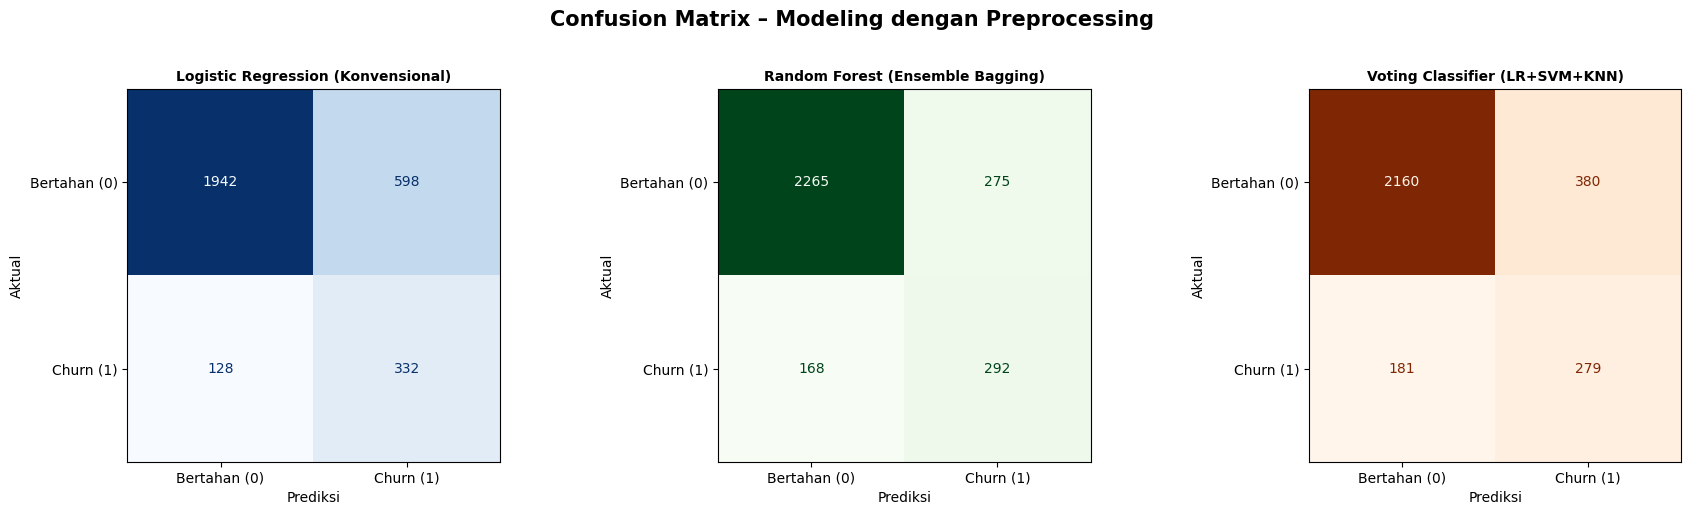

In [35]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix – Modeling dengan Preprocessing',
             fontsize=15, fontweight='bold', y=1.02)

colors_cm = ['Blues', 'Greens', 'Oranges']

for ax, (name, y_pred), cmap in zip(axes, preds_prep.items(), colors_cm):
    cm = confusion_matrix(y_test_p, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Bertahan (0)', 'Churn (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format='d')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()

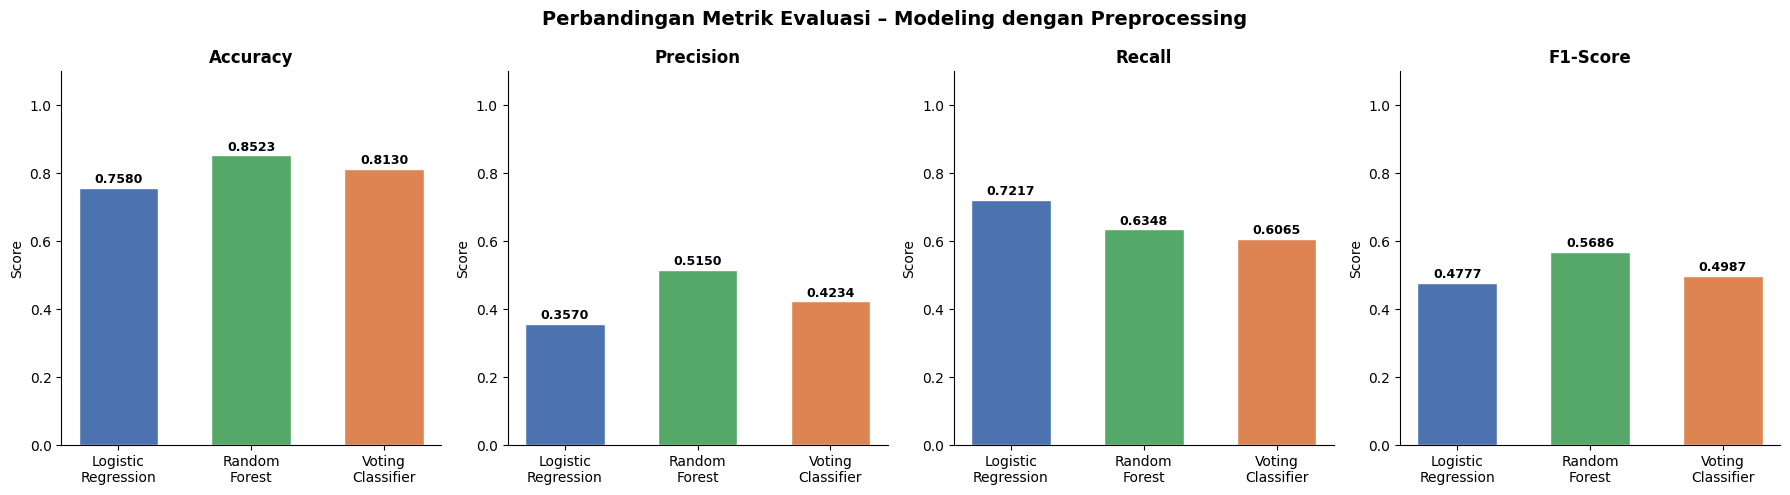

In [36]:
# Perbandingan metrik antar model
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names_short = ['Logistic\nRegression', 'Random\nForest', 'Voting\nClassifier']
palette = ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Perbandingan Metrik Evaluasi – Modeling dengan Preprocessing',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_names):
    values = results_df_prep[metric].values
    bars = ax.bar(model_names_short, values, color=palette, edgecolor='white', width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_comparison_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()

PERBANDINGAN F1-SCORE: Direct vs Preprocessing
                     F1 Direct  F1 Preprocessing
Model                                           
Logistic Regression     0.2118            0.4777
Random Forest           0.4255            0.5686
Voting Classifier       0.0532            0.4987


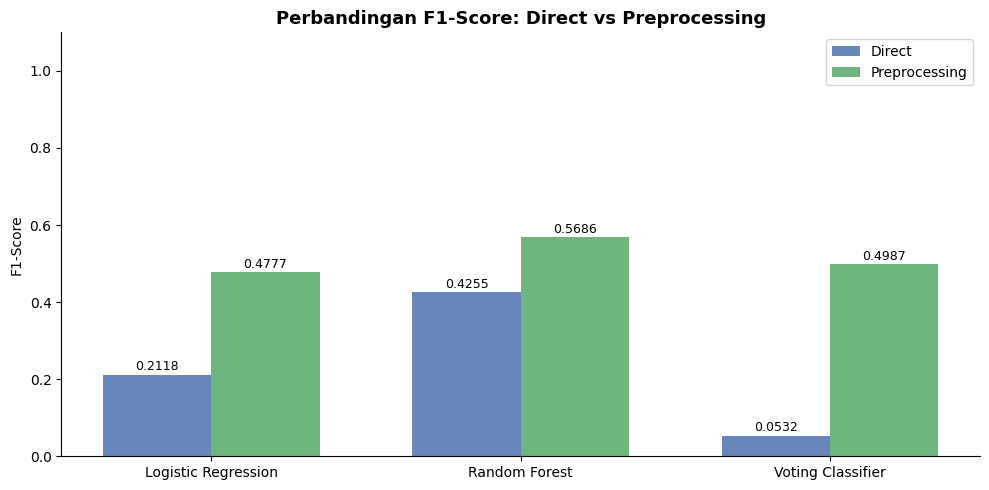


Model terbaik berdasarkan F1-Score pada Preprocessing:
Random Forest (Ensemble Bagging) (F1-Score = 0.5686)


In [37]:
# Perbandingan Direct vs Preprocessing (F1-Score)
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Voting Classifier'],
    'F1 Direct'       : results_df_direct['F1-Score'].values,
    'F1 Preprocessing': results_df_prep['F1-Score'].values,
}
comp_df = pd.DataFrame(comparison_data).set_index('Model')

print('PERBANDINGAN F1-SCORE: Direct vs Preprocessing')
print(comp_df.to_string(float_format=lambda x: f'{x:.4f}'))

# Visualisasi
x_pos = np.arange(len(comp_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, comp_df['F1 Direct'],        width, label='Direct',        color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, comp_df['F1 Preprocessing'], width, label='Preprocessing', color='#55A868', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(comp_df.index)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan F1-Score: Direct vs Preprocessing', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nModel terbaik berdasarkan F1-Score pada Preprocessing:')
best_prep = results_df_prep['F1-Score'].idxmax()
print(f'{best_prep} (F1-Score = {results_df_prep.loc[best_prep, "F1-Score"]:.4f})')

# Hyperparameter Tuning dan Feature Selection

### 1. Analisis Feature Importance

In [38]:
# Gunakan Random Forest dari hasil preprocessing untuk ekstrak feature importance (karena RF memiliki built-in feature importance berbasis mean decrease impurity)
rf_model = trained_prep['Random Forest (Ensemble Bagging)']

feature_names = X_prep.columns.tolist()
importances   = rf_model.feature_importances_

fi_df = pd.DataFrame({'Fitur': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 15 Fitur Terpenting:')
print(fi_df.head(15).to_string(index=False))

Top 15 Fitur Terpenting:
                     Fitur  Importance
        satisfaction_score    0.251116
               total_spent    0.186874
           support_tickets    0.082857
                    gender    0.044141
             discount_used    0.031144
       delivery_delay_days    0.027154
         subscription_type    0.025778
                 nps_score    0.022629
  marketing_spend_per_user    0.019757
          email_click_rate    0.019132
last_3_month_purchase_freq    0.019023
              total_visits    0.018970
               tenure_days    0.018471
  days_since_last_purchase    0.018419
           email_open_rate    0.018289


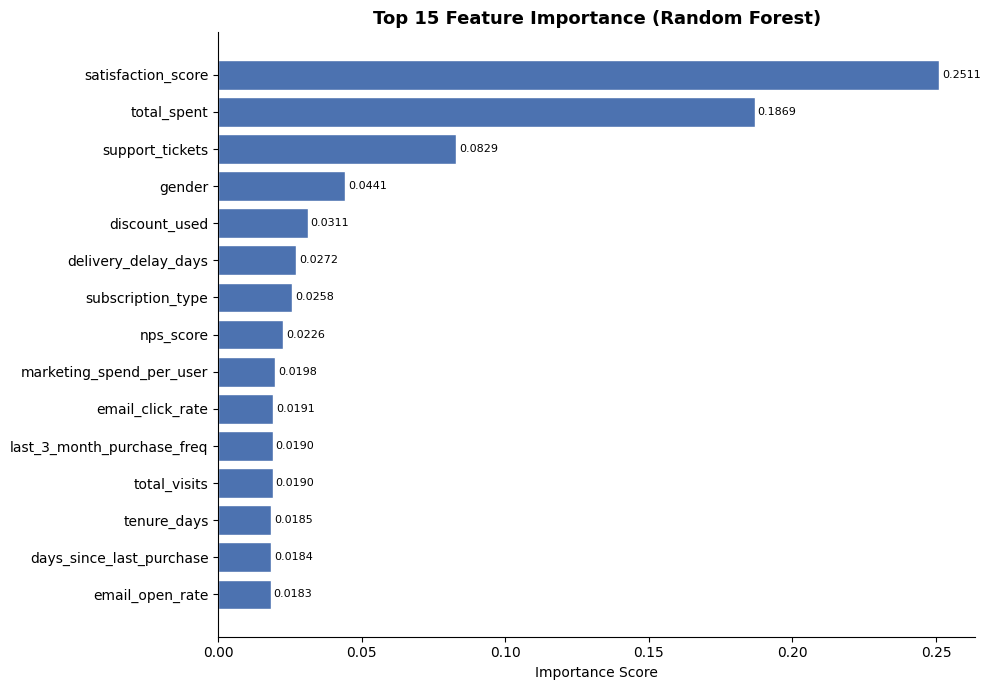


Jumlah fitur terpilih (kumulatif importance ≥95%): 27
Fitur terpilih: ['satisfaction_score', 'total_spent', 'support_tickets', 'gender', 'discount_used', 'delivery_delay_days', 'subscription_type', 'nps_score', 'marketing_spend_per_user', 'email_click_rate', 'last_3_month_purchase_freq', 'total_visits', 'tenure_days', 'days_since_last_purchase', 'email_open_rate', 'lifetime_value', 'avg_order_value', 'avg_session_time', 'pages_per_session', 'age', 'is_premium_user', 'device_type_Mobile', 'device_type_Tablet', 'country_Germany', 'refund_requested', 'acquisition_channel_Google Ads', 'country_India']


In [39]:
# Visualisasi Top 15 Feature Importance
top_n = 15
fi_top = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fi_top['Fitur'][::-1], fi_top['Importance'][::-1],
               color='#4C72B0', edgecolor='white')
for bar, val in zip(bars, fi_top['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Feature Importance (Random Forest)',
             fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Pilih fitur dengan importance > threshold (kumulatif 95%)
fi_df['Cumulative'] = fi_df['Importance'].cumsum()
selected_features = fi_df[fi_df['Cumulative'] <= 0.95]['Fitur'].tolist()
# Pastikan minimal 10 fitur terpilih
if len(selected_features) < 10:
    selected_features = fi_df.head(10)['Fitur'].tolist()

print(f'\nJumlah fitur terpilih (kumulatif importance ≥95%): {len(selected_features)}')
print('Fitur terpilih:', selected_features)

In [40]:
# Buat dataset dengan fitur terpilih untuk tuning
X_prep_sel = X_prep[selected_features]

# Train-test split ulang dengan fitur terpilih
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_prep_sel, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

# Scaling
scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

# SMOTE pada data latih
smote_sel = SMOTE(random_state=42)
X_train_sel_res, y_train_sel_res = smote_sel.fit_resample(X_train_sel_sc, y_train_sel)

print(f'Shape data latih setelah feature selection + SMOTE : {X_train_sel_res.shape}')
print(f'Shape data uji                                     : {X_test_sel_sc.shape}')

Shape data latih setelah feature selection + SMOTE: (20324, 27)
Shape data uji                                     : (3000, 27)


### 2. Penyusunan Parameter Grid Hyperparameter

In [41]:
# 1. Logistic Regression
param_grid_lr = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [1000],
}

# 2. Random Forest
param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

# 3. Voting Classifier
# Tuning komponen LR dan KNN di dalam VotingClassifier
param_grid_vc = {
    'lr__C'           : [0.1, 1, 10],
    'lr__max_iter'    : [1000],
    'knn__n_neighbors': [3, 5, 7, 11],
    'knn__weights'    : ['uniform', 'distance'],
}

print('Parameter grid telah disusun untuk ketiga model.')
print(f'  LR  — kombinasi: {len(param_grid_lr["C"]) * len(param_grid_lr["solver"])} kombinasi')
print(f'  RF  — kombinasi: {3*4*3*3*2} kombinasi (sebelum RandomizedSearch sampling)')
print(f'  VC  — kombinasi: {3*4*2} kombinasi')

Parameter grid telah disusun untuk ketiga model.
  LR  — kombinasi: 10 kombinasi
  RF  — kombinasi: 216 kombinasi (sebelum RandomizedSearch sampling)
  VC  — kombinasi: 24 kombinasi


### 3. Proses Hyperparameter Tuning

In [42]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Logistic Regression — GridSearchCV (ruang kecil)
print('Tuning Logistic Regression dengan GridSearchCV...')
base_lr = LogisticRegression(random_state=42)
gs_lr = GridSearchCV(
    base_lr, param_grid_lr,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_sel_res, y_train_sel_res)
print(f'  Selesai. Best F1 (CV): {gs_lr.best_score_:.4f}')
print(f'  Best params: {gs_lr.best_params_}\n')

Tuning Logistic Regression dengan GridSearchCV...
  Selesai. Best F1 (CV): 0.7803
  Best params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}



In [44]:
# Random Forest — RandomizedSearchCV (ruang besar)
print('Tuning Random Forest dengan RandomizedSearchCV...')
base_rf = RandomForestClassifier(random_state=42)
rs_rf = RandomizedSearchCV(
    base_rf, param_grid_rf,
    n_iter=10, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
rs_rf.fit(X_train_sel_res, y_train_sel_res)
print(f'  Selesai. Best F1 (CV): {rs_rf.best_score_:.4f}')
print(f'  Best params: {rs_rf.best_params_}\n')

Tuning Random Forest dengan RandomizedSearchCV...
  Selesai. Best F1 (CV): 0.9070
  Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}



In [45]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

linear_svc = CalibratedClassifierCV(
    LinearSVC(random_state=42, max_iter=1000)
)

print('Tuning Voting Classifier dengan GridSearchCV...')
base_vc = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
        ('svm', linear_svc),
        ('knn', KNeighborsClassifier()),
    ],
    voting='soft'
)
gs_vc = GridSearchCV(
    base_vc, param_grid_vc,
    cv=3, scoring='f1', n_jobs=-1, verbose=0
)
gs_vc.fit(X_train_sel_res, y_train_sel_res)
print(f'  Selesai. Best F1 (CV): {gs_vc.best_score_:.4f}')
print(f'  Best params: {gs_vc.best_params_}\n')

Tuning Voting Classifier dengan GridSearchCV...
  Selesai. Best F1 (CV): 0.8673
  Best params: {'knn__n_neighbors': 3, 'knn__weights': 'distance', 'lr__C': 0.1, 'lr__max_iter': 1000}



### 4. Best Estimator dan Best Parameters

In [46]:
tuning_results = {
    'Logistic Regression (Konvensional)': gs_lr,
    'Random Forest (Ensemble Bagging)'  : rs_rf,
    'Voting Classifier (LR+SVM+KNN)'   : gs_vc,
}

print('PARAMETER TERBAIK HASIL TUNING')
for name, search in tuning_results.items():
    print(f'\n► {name}')
    print(f'  Best CV F1-Score : {search.best_score_:.4f}')
    print(f'  Best Parameters  : {search.best_params_}')

PARAMETER TERBAIK HASIL TUNING

► Logistic Regression (Konvensional)
  Best CV F1-Score : 0.7803
  Best Parameters  : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

► Random Forest (Ensemble Bagging)
  Best CV F1-Score : 0.9070
  Best Parameters  : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

► Voting Classifier (LR+SVM+KNN)
  Best CV F1-Score : 0.8673
  Best Parameters  : {'knn__n_neighbors': 3, 'knn__weights': 'distance', 'lr__C': 0.1, 'lr__max_iter': 1000}


### 5. Melatih Ulang Best Estimator pada Data Latih

In [47]:
best_models_tuned = {}

for name, search in tuning_results.items():
    best_est = search.best_estimator_
    best_est.fit(X_train_sel_res, y_train_sel_res)
    best_models_tuned[name] = best_est
    print(f'✓ {name} — retrained dengan best params.')

print('\nSemua best estimator berhasil dilatih ulang!')

✓ Logistic Regression (Konvensional) — retrained dengan best params.
✓ Random Forest (Ensemble Bagging) — retrained dengan best params.
✓ Voting Classifier (LR+SVM+KNN) — retrained dengan best params.

Semua best estimator berhasil dilatih ulang!


### 6. Evaluasi Performa Model Optimal

In [48]:
results_tuned = []
preds_tuned   = {}

for name, model in best_models_tuned.items():
    y_pred = model.predict(X_test_sel_sc)
    preds_tuned[name] = y_pred
    results_tuned.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test_sel, y_pred),
        'Precision': precision_score(y_test_sel, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test_sel, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test_sel, y_pred, zero_division=0),
    })

results_df_tuned = pd.DataFrame(results_tuned).set_index('Model')
print('RINGKASAN METRIK EVALUASI - HYPERPARAMETER TUNING')
print(results_df_tuned.to_string(float_format=lambda x: f'{x:.4f}'))

RINGKASAN METRIK EVALUASI - HYPERPARAMETER TUNING
                                    Accuracy  Precision  Recall  F1-Score
Model                                                                    
Logistic Regression (Konvensional)    0.7480     0.3465  0.7261    0.4691
Random Forest (Ensemble Bagging)      0.8573     0.5235  0.7761    0.6252
Voting Classifier (LR+SVM+KNN)        0.7563     0.3526  0.7043    0.4699


In [49]:
# Classification Report per model
for name, y_pred in preds_tuned.items():
    print(f'Classification Report: {name}')
    print(classification_report(y_test_sel, y_pred, target_names=['Bertahan (0)', 'Churn (1)']))

Classification Report: Logistic Regression (Konvensional)
              precision    recall  f1-score   support

Bertahan (0)       0.94      0.75      0.83      2540
   Churn (1)       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000

Classification Report: Random Forest (Ensemble Bagging)
              precision    recall  f1-score   support

Bertahan (0)       0.96      0.87      0.91      2540
   Churn (1)       0.52      0.78      0.63       460

    accuracy                           0.86      3000
   macro avg       0.74      0.82      0.77      3000
weighted avg       0.89      0.86      0.87      3000

Classification Report: Voting Classifier (LR+SVM+KNN)
              precision    recall  f1-score   support

Bertahan (0)       0.93      0.77      0.84      2540
   Churn (1)       0.35      0.70      0.47       460

    accuracy  

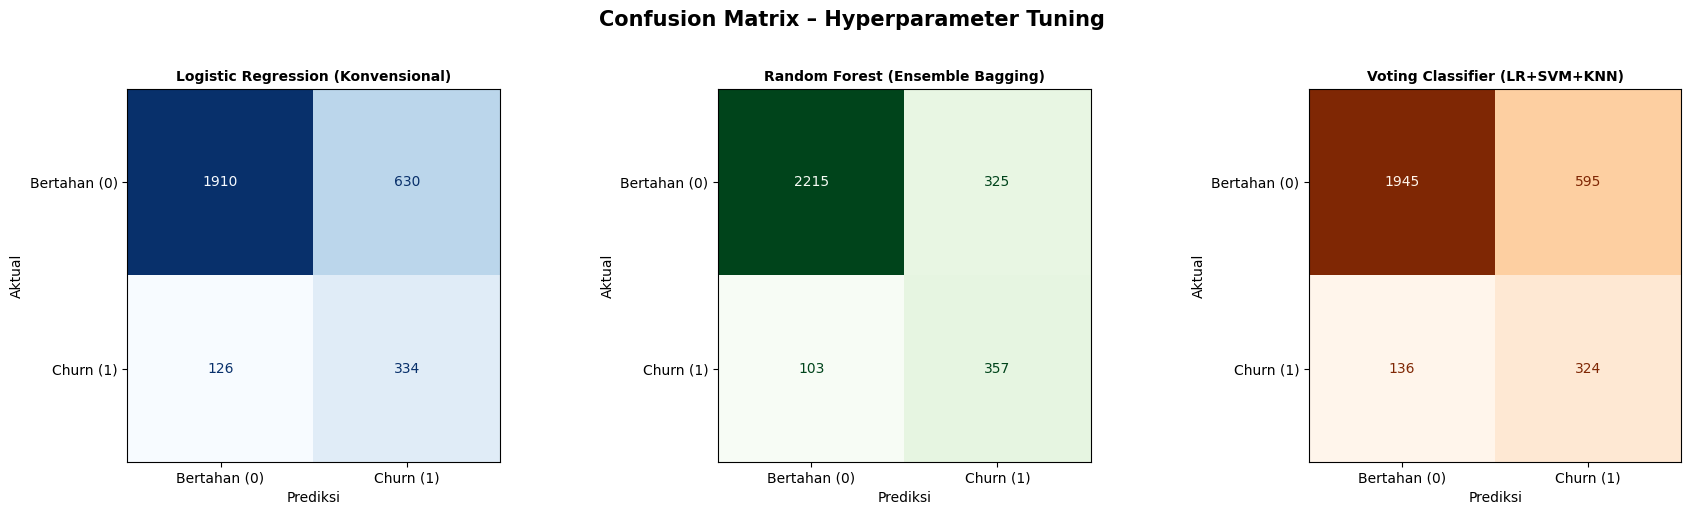

In [50]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix – Hyperparameter Tuning',
             fontsize=15, fontweight='bold', y=1.02)

colors_cm = ['Blues', 'Greens', 'Oranges']
for ax, (name, y_pred), cmap in zip(axes, preds_tuned.items(), colors_cm):
    cm = confusion_matrix(y_test_sel, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Bertahan (0)', 'Churn (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format='d')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', bbox_inches='tight', dpi=150)
plt.show()

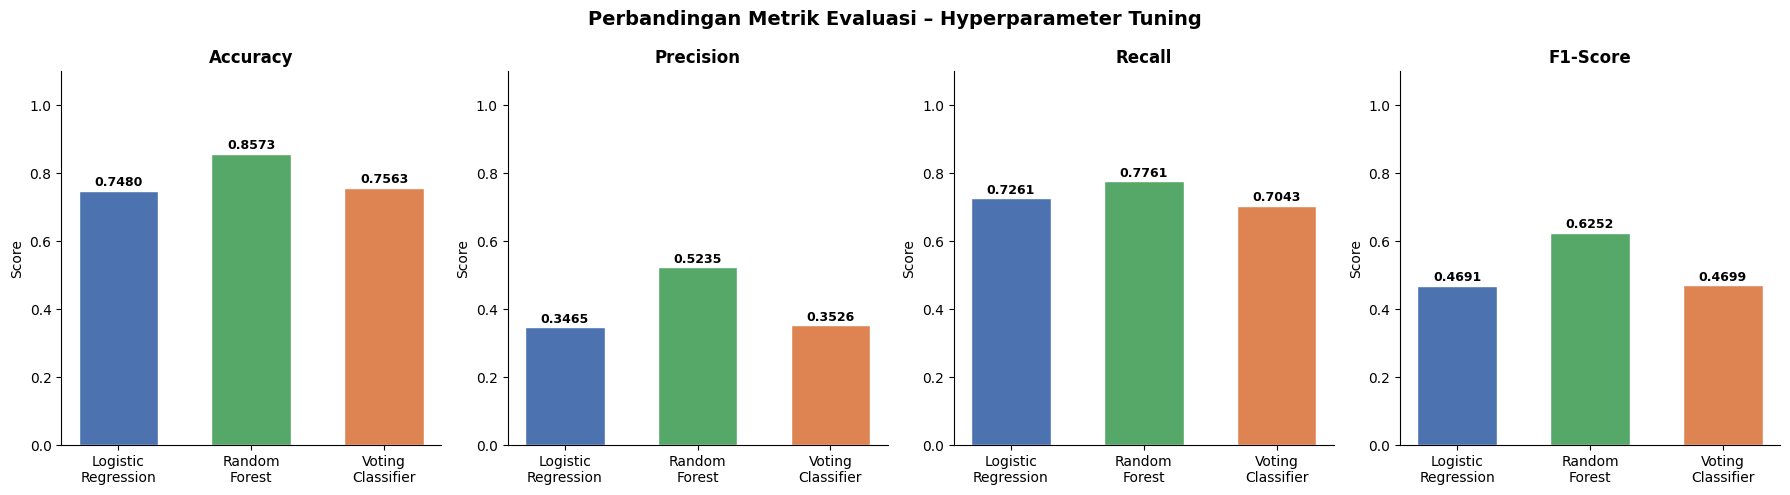

In [51]:
# Perbandingan metrik antar model
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names_short = ['Logistic\nRegression', 'Random\nForest', 'Voting\nClassifier']
palette = ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Perbandingan Metrik Evaluasi – Hyperparameter Tuning',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_names):
    values = results_df_tuned[metric].values
    bars = ax.bar(model_names_short, values, color=palette, edgecolor='white', width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_comparison_tuned.png', bbox_inches='tight', dpi=150)
plt.show()

PERBANDINGAN F1-SCORE:
                     F1 Direct  F1 Preprocessing  F1 Tuning
Model                                                      
Logistic Regression     0.2118            0.4777     0.4691
Random Forest           0.4255            0.5686     0.6252
Voting Classifier       0.0532            0.4987     0.4699


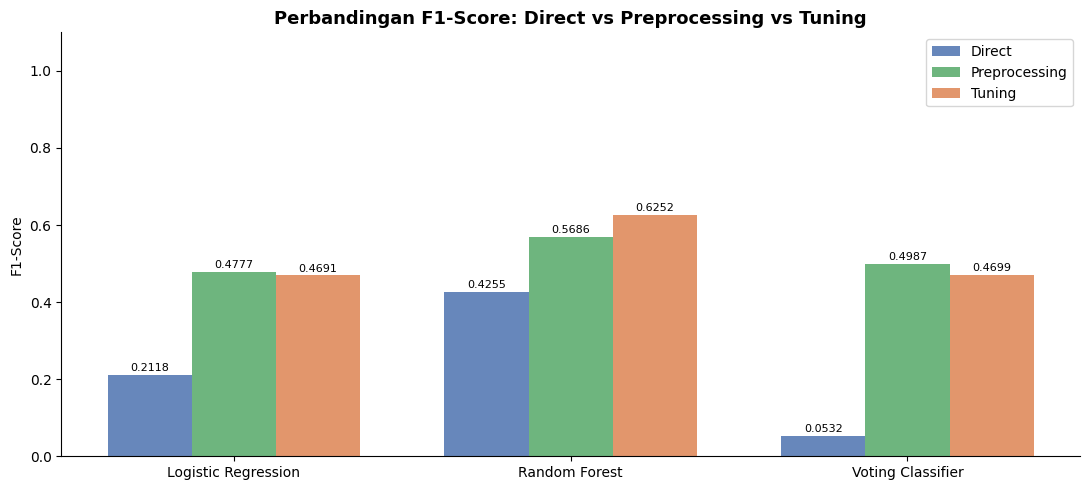


Model terbaik keseluruhan berdasarkan F1-Score (Tuning):
  ➜ Random Forest (Ensemble Bagging)
     Accuracy  : 0.8573
     Precision : 0.5235
     Recall    : 0.7761
     F1-Score  : 0.6252


In [52]:
# Perbandingan F1-Score: Direct vs Preprocessing vs Tuning
comp_all = pd.DataFrame({
    'Model'         : ['Logistic Regression', 'Random Forest', 'Voting Classifier'],
    'F1 Direct'     : results_df_direct['F1-Score'].values,
    'F1 Preprocessing': results_df_prep['F1-Score'].values,
    'F1 Tuning'     : results_df_tuned['F1-Score'].values,
}).set_index('Model')

print('PERBANDINGAN F1-SCORE:')
print(comp_all.to_string(float_format=lambda x: f'{x:.4f}'))

# Visualisasi grouped bar
x_pos = np.arange(len(comp_all))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x_pos - width, comp_all['F1 Direct'],        width, label='Direct',        color='#4C72B0', alpha=0.85)
b2 = ax.bar(x_pos,         comp_all['F1 Preprocessing'], width, label='Preprocessing', color='#55A868', alpha=0.85)
b3 = ax.bar(x_pos + width, comp_all['F1 Tuning'],        width, label='Tuning',        color='#DD8452', alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(comp_all.index)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan F1-Score: Direct vs Preprocessing vs Tuning',
             fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_all_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nModel terbaik keseluruhan berdasarkan F1-Score (Tuning):')
best_overall = results_df_tuned['F1-Score'].idxmax()
print(f'  ➜ {best_overall}')
print(f'     Accuracy  : {results_df_tuned.loc[best_overall, "Accuracy"]:.4f}')
print(f'     Precision : {results_df_tuned.loc[best_overall, "Precision"]:.4f}')
print(f'     Recall    : {results_df_tuned.loc[best_overall, "Recall"]:.4f}')
print(f'     F1-Score  : {results_df_tuned.loc[best_overall, "F1-Score"]:.4f}')

# Deployment

### Menyiapkan dan Menyimpan Model Terbaik

In [53]:
import joblib
import os

# Model terbaik: Random Forest (Ensemble Bagging) dengan F1-Score = 0.6252
best_model = best_models_tuned['Random Forest (Ensemble Bagging)']

# Buat folder deployment
os.makedirs('deployment', exist_ok=True)

# Simpan model
joblib.dump(best_model, 'deployment/best_model_rf.joblib')

# Simpan scaler (dibutuhkan untuk transform data input baru)
joblib.dump(scaler_sel, 'deployment/scaler.joblib')

# Simpan daftar fitur yang digunakan model
joblib.dump(selected_features, 'deployment/selected_features.joblib')

print('File tersimpan:')
for f in os.listdir('deployment'):
    size = os.path.getsize(f'deployment/{f}') / 1024
    print(f'  deployment/{f}  ({size:.1f} KB)')

# Verifikasi model dapat dimuat kembali
model_check = joblib.load('deployment/best_model_rf.joblib')
print(f'\nVerifikasi model berhasil dimuat: {type(model_check).__name__}')

File tersimpan:
  deployment/best_model_rf.joblib  (15272.7 KB)
  deployment/scaler.joblib  (2.0 KB)
  deployment/selected_features.joblib  (0.5 KB)

Verifikasi model berhasil dimuat: RandomForestClassifier
